# SageMaker notebooks-1773713276278

Job Change Predictions

## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'cmckkznmg9e4dj'
os.environ['DataZoneDomainId'] = 'dzd-dno1z7uulwn65j'
os.environ['DataZoneEnvironmentId'] = 'd019csgggfio13'
os.environ['DataZoneDomainRegion'] = 'us-east-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "cmckkznmg9e4dj",
                "DataZoneDomainId": "dzd-dno1z7uulwn65j",
                "DataZoneEnvironmentId": "d019csgggfio13",
                "DataZoneDomainRegion": "us-east-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

In [0]:
import pandas as pd
import sklearn
import xgboost

## 1. Read Data

Load your dataset and verify that all columns and rows are displayed correctly


In [0]:
import pandas as pd

df = pd.read_parquet("s3://job-change-github/processed/")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,senior_candidate
0,8949,103,0.920,1,1,0,3,STEM,21.0,0,0,1,36,1,1
1,29725,40,0.776,1,0,0,3,STEM,15.0,3,1,5,47,0,1
2,11561,21,0.624,0,0,1,3,STEM,5.0,0,0,0,83,0,0
3,33241,115,0.789,0,0,3,3,Business Degree,0.0,0,1,0,52,1,0
4,666,162,0.767,1,1,0,4,STEM,21.0,3,2,4,8,0,1


## 2. Review Data Type

Verify that each column is shown in the specified format (for this scenario, should be: int or float) .


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  object 
 1   city                    19158 non-null  int32  
 2   city_development_index  19158 non-null  float32
 3   gender                  19158 non-null  int32  
 4   relevent_experience     19158 non-null  int32  
 5   enrolled_university     19158 non-null  int32  
 6   education_level         19158 non-null  int32  
 7   major_discipline        19158 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            19158 non-null  int32  
 10  company_type            19158 non-null  int32  
 11  last_new_job            19158 non-null  int32  
 12  training_hours          19158 non-null  object 
 13  target                  19158 non-null  int32  
 14  senior_candidate        19158 non-null

## 3. Review Null Values

Check for missing values in each column. Plan to fill or handle any null values.


In [0]:
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
senior_candidate          0
dtype: int64

## 4. Change Null Values

Fill missing values in the dataset, either with the column mean or zeros.

In [0]:
df["experience"] = df["experience"].fillna(df["experience"].mean())

## 5. Convert Data Type and Drop Columns

Convert "training_hours" from object to integer type. Drop the columns "enrollee_id and major_discipline"


In [0]:
df = df.drop(columns=["enrollee_id"])
df = df.drop(columns=["major_discipline"])
df["training_hours"] = df["training_hours"].astype(int)

## 6. Define and Separate Data

x: all predictable variables. axis = 0 (columns) axis =1 (rows)
The rest of the columns that isn´t "target" will be your x variable.
y: objective variable (column target, stores numbers 0 and 1)
0= Won´t change the job. 1= Will change the job

In [0]:
X = df.drop("target", axis=1)
y = df["target"]

## 7. Divide training and test Data

Data to train the model. Data to test the model.
X_train: Entry data for the train model.  X_test= Entry data for the test model.
y_train: Correct answers for the train model.  y_test= Correct answers for the test model.
test_size: 80% training 20% test
random_state: divide dataset

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Prediction and Objective variables
n_ estimators: decision makers (more estimators, slower but more precise)
max_depth: maximum depth of each tree (how complex a model could be)
learning_rate: how fast the model learns (small number learns slowly but with more preccision)
X_train: prediction variable. y_train: objective variables


In [0]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 9. Predict results


In [0]:
y_pred = model.predict(X_test)

## 10. Model Accuracy

The accuracy will show the percentage of correct answers.
y_test: (values from the dataset)
y_pred: (prediction value by the model)

In [0]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.784446764091858


## 11. Importance Columns

Identify which features most influence the model.
Feature: name of the variable
Importance: influence of the variable for the model


In [0]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                   Feature  Importance
1   city_development_index    0.249710
8             company_type    0.241801
5          education_level    0.087733
3      relevent_experience    0.072564
11        senior_candidate    0.065927
7             company_size    0.061966
9             last_new_job    0.045205
6               experience    0.037051
4      enrolled_university    0.035838
0                     city    0.035308
10          training_hours    0.033760
2                   gender    0.033137


## 12. Confusion Matrix Graph

Shows the accuracy of the prediction against actual data.
True Negative (TN) = Prediction: 0 and Data: 0
False Positive (FP) = Prediction: 1 and Data: 0
False Negative (FN) = Prediction: 0 and Data: 1
True Positive(TP) = Prediction: 1 and Data: 1

annot= Trueshows the numbers
fmt= "d"	shows int numbers
cmap= "Blues" use blue colors

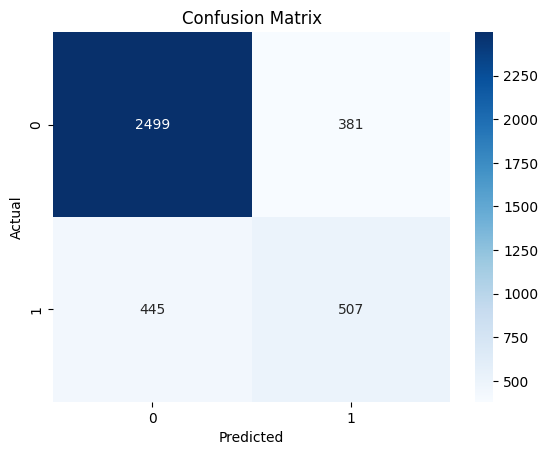

In [0]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 13. Stats (precision, recall and f1-score)

precission: TP / (TP + FP)
recall: TP / (TP + FN)
f1-score: 2 * (precision * recall) / (precision + recall)
support: total number of data 


In [0]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      2880
           1       0.57      0.53      0.55       952

    accuracy                           0.78      3832
   macro avg       0.71      0.70      0.70      3832
weighted avg       0.78      0.78      0.78      3832



## 14. Importance Columns

Identify which features most influence the model. Feature: name of the variable Importance: influence of the variable for the model


In [0]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                   Feature  Importance
1   city_development_index    0.249710
8             company_type    0.241801
5          education_level    0.087733
3      relevent_experience    0.072564
11        senior_candidate    0.065927
7             company_size    0.061966
9             last_new_job    0.045205
6               experience    0.037051
4      enrolled_university    0.035838
0                     city    0.035308
10          training_hours    0.033760
2                   gender    0.033137


## 15. Importance Graph Bar

Visualize feature importance using a bar graph


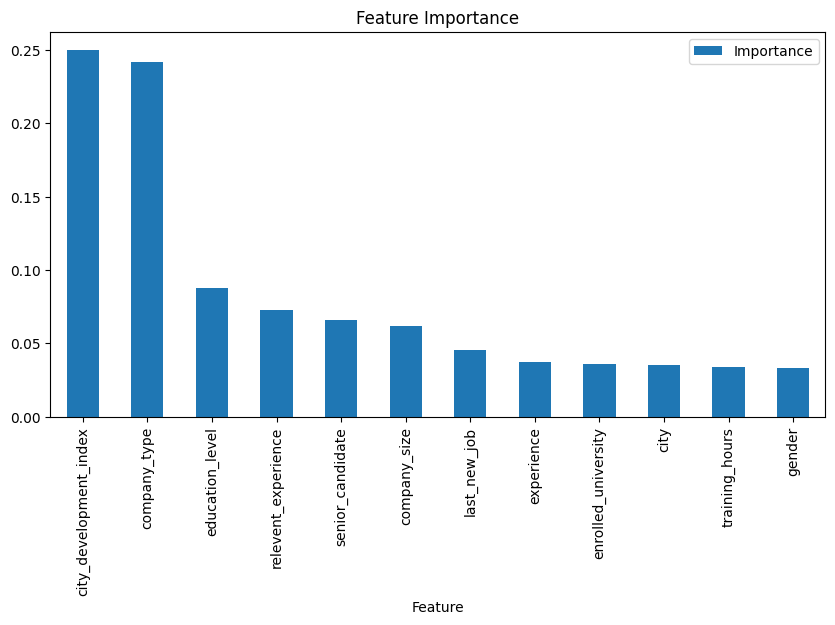

In [0]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

## IMPROVEMENTS

In [0]:
import pandas as pd

df = pd.read_parquet("s3://job-change-github/processed/")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,senior_candidate
0,8949,103,0.920,1,1,0,3,STEM,21.0,0,0,1,36,1,1
1,29725,40,0.776,1,0,0,3,STEM,15.0,3,1,5,47,0,1
2,11561,21,0.624,0,0,1,3,STEM,5.0,0,0,0,83,0,0
3,33241,115,0.789,0,0,3,3,Business Degree,0.0,0,1,0,52,1,0
4,666,162,0.767,1,1,0,4,STEM,21.0,3,2,4,8,0,1


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  object 
 1   city                    19158 non-null  int32  
 2   city_development_index  19158 non-null  float32
 3   gender                  19158 non-null  int32  
 4   relevent_experience     19158 non-null  int32  
 5   enrolled_university     19158 non-null  int32  
 6   education_level         19158 non-null  int32  
 7   major_discipline        19158 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            19158 non-null  int32  
 10  company_type            19158 non-null  int32  
 11  last_new_job            19158 non-null  int32  
 12  training_hours          19158 non-null  object 
 13  target                  19158 non-null  int32  
 14  senior_candidate        19158 non-null

In [0]:
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
senior_candidate          0
dtype: int64

In [0]:
df["experience"] = df["experience"].fillna(df["experience"].mean())

In [0]:
df = df.drop(columns=["enrollee_id"])
df = df.drop(columns=["major_discipline"])
df["training_hours"] = df["training_hours"].astype(int)

In [0]:
X = df.drop("target", axis=1)
y = df["target"]

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 16.  Correct unbalanced data
scale: Total times when y_train=0 divided by total times  when y_train=1. The result will show how many times one results it shows compared to the other. 
Depending on the result the model will determine which variable is more important to make a balance.
(EX: 2300/760  =3) This means the results with variables with y_train=1 should be 3 times more important than 0.
scale_pos_weight= extra weight for the minority class

In [0]:
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

## 17. Adjust hyperparameters
n_ estimators: trees decision makers (more estimators, more precision but slower) 
max_depth: how complex a model could be 
learning_rate: how fast the model learns (small number learns slowly but with more preccision) 
subsamlple: random samples to avoid overfitting (rows)
colsample_bytree: fraction of features used per tree (columns)
X_train: prediction variable. y_train: objective variables

In [0]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.07,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42
    
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [0]:
y_pred = model.predict(X_test)

In [0]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7750521920668059


In [0]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                   Feature  Importance
8             company_type    0.206363
1   city_development_index    0.165477
0                     city    0.091098
5          education_level    0.085817
3      relevent_experience    0.076359
7             company_size    0.069998
9             last_new_job    0.055967
4      enrolled_university    0.054225
6               experience    0.051922
11        senior_candidate    0.048290
10          training_hours    0.047408
2                   gender    0.047073


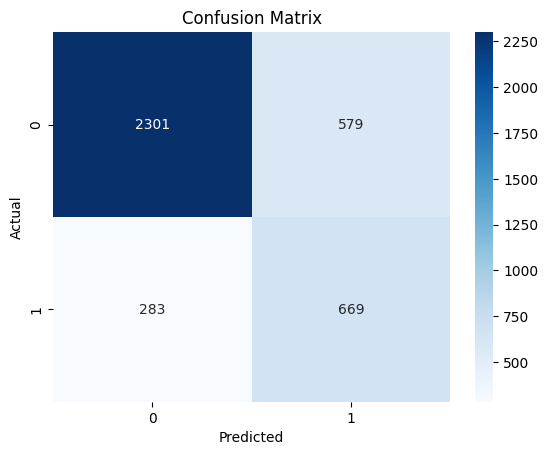

In [0]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 18. Results with the new parameters and scaling
Compare results with previous model. Accuracy may be similar, but recall for predicting job change improved from 53% to 70%.

In [0]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2880
           1       0.54      0.70      0.61       952

    accuracy                           0.78      3832
   macro avg       0.71      0.75      0.73      3832
weighted avg       0.80      0.78      0.78      3832



## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()